In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
from pathlib import Path

matplotlib.rcParams['mathtext.fontset'] = 'cm'

output_dir = Path('figures')
output_dir.mkdir(exist_ok=True)

# Figure config (matching MRI notebook)
fig_width  = 3.25
fig_height = 2.6

LABEL_FONTSIZE  = 14
TICK_LABELSIZE  = 12
LEGEND_FONTSIZE = 12
LINEWIDTH       = 2.5
GRID_ALPHA      = 0.2
TIGHT_PAD       = 0.5

COLOR_RAW     = '#7f7f7f'
COLOR_RETRAIN = '#d62728'
COLOR_UNCOND  = '#ff7f0e'
COLOR_COND    = '#1f77b4'

FRACS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

## Data
Results from multi-ablation runs (100 train ablations × n_train, 400 eval ablations × n_test per fraction).

In [2]:
# PhysioNet — binary, 118 features, lr=0.1, 20k steps
physionet = {
    'raw':     [4.9940e-03, 2.2034e-02, 4.9419e-02, 9.2161e-02, 1.4972e-01,
                2.1204e-01, 2.9452e-01, 4.0279e-01, 5.4153e-01],
    'retrain': [6.8197e-05, 2.0991e-04, 4.4116e-04, 1.0689e-03, 2.8669e-03,
                6.5067e-03, 1.9530e-02, 6.6042e-02, 2.1786e-01],
    'uncond':  [1.8997e-06, 7.5061e-04, 3.3217e-03, 8.8449e-03, 2.1540e-02,
                3.8871e-02, 7.4307e-02, 1.5238e-01, 3.2121e-01],
    'cond':    [3.7935e-03, 8.5215e-03, 1.3936e-02, 1.5731e-02, 2.1451e-02,
                1.9114e-02, 2.1999e-02, 1.2157e-02, 5.4470e-02],
}

# CTG — 3-class, 21 features
ctg = {
    'raw':     [9.2095e-04, 6.3465e-03, 1.8036e-02, 3.7387e-02, 6.7121e-02,
                1.0498e-01, 1.5272e-01, 2.0948e-01, 2.8091e-01],
    'retrain': [1.0885e-04, 7.5497e-04, 2.1915e-03, 4.1311e-03, 7.7844e-03,
                1.5149e-02, 3.0856e-02, 7.0188e-02, 1.6298e-01],
    'uncond':  [9.2718e-03, 6.9920e-03, 3.8097e-03, 2.4347e-03, 4.8257e-03,
                1.4347e-02, 4.0250e-02, 9.5653e-02, 2.0371e-01],
    'cond':    [9.4409e-04, 9.1992e-04, 1.7033e-03, 3.8308e-03, 6.6334e-03,
                1.0229e-02, 1.9995e-02, 3.6067e-02, 7.3232e-02],
}

# Breast Cancer — binary, 30 features
breast_cancer = {
    'raw':     [4.8282e-04, 2.1091e-03, 6.1480e-03, 2.1296e-02, 6.2868e-02,
                1.4316e-01, 2.8930e-01, 4.7059e-01, 5.9815e-01],
    'retrain': [4.6558e-05, 8.2341e-06, 3.5900e-05, 2.4768e-04, 8.4984e-04,
                2.4343e-03, 9.4648e-03, 4.5694e-02, 2.0770e-01],
    'uncond':  [8.8896e-03, 7.2400e-03, 4.6960e-03, 2.0940e-03, 5.9598e-05,
                2.2381e-03, 2.4770e-02, 1.0854e-01, 3.2918e-01],
    'cond':    [1.6866e-04, 1.1782e-04, 3.5438e-06, 3.0940e-06, 1.0984e-06,
                2.6749e-05, 7.5596e-04, 4.4669e-03, 2.5435e-02],
}

datasets = [
    ('PhysioNet',     physionet,     'physionet'),
    ('CTG',           ctg,           'ctg'),
    ('Breast Cancer', breast_cancer, 'breast_cancer'),
]

methods = [
    ('raw',     'Base',    COLOR_RAW,     '--', 1.5),
    ('retrain', 'Retrain', COLOR_RETRAIN, '-',  LINEWIDTH),
    ('uncond',  'Uncond',  COLOR_UNCOND,  '-',  LINEWIDTH),
    ('cond',    'Cond',    COLOR_COND,    '-',  LINEWIDTH),
]

## PhysioNet

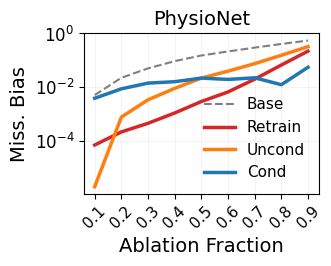

Saved: figures/physionet_kl_fractionwise.pdf


In [3]:
title, data, fname = datasets[0]

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

for key, label, color, ls, lw in methods:
    ax.plot(FRACS, data[key], linestyle=ls, linewidth=lw,
            color=color, label=label)

ax.set_xlabel('Ablation Fraction', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
ax.set_yscale('log')
ax.set_xticks(FRACS)
ax.set_xticklabels([str(f) for f in FRACS], rotation=45, fontsize=TICK_LABELSIZE - 1)
ax.tick_params(axis='y', which='major', labelsize=TICK_LABELSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE - 1, loc='lower right', frameon=False)
ax.grid(True, alpha=GRID_ALPHA, linewidth=0.5)
ax.set_title(title, fontsize=LABEL_FONTSIZE)

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / f'{fname}_kl_fractionwise.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / f'{fname}_kl_fractionwise.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: figures/{fname}_kl_fractionwise.pdf')

## CTG

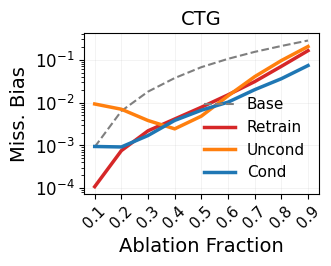

Saved: figures/ctg_kl_fractionwise.pdf


In [4]:
title, data, fname = datasets[1]

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

for key, label, color, ls, lw in methods:
    ax.plot(FRACS, data[key], linestyle=ls, linewidth=lw,
            color=color, label=label)

ax.set_xlabel('Ablation Fraction', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
ax.set_yscale('log')
ax.set_xticks(FRACS)
ax.set_xticklabels([str(f) for f in FRACS], rotation=45, fontsize=TICK_LABELSIZE - 1)
ax.tick_params(axis='y', which='major', labelsize=TICK_LABELSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE - 1, loc='lower right', frameon=False)
ax.grid(True, alpha=GRID_ALPHA, linewidth=0.5)
ax.set_title(title, fontsize=LABEL_FONTSIZE)

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / f'{fname}_kl_fractionwise.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / f'{fname}_kl_fractionwise.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: figures/{fname}_kl_fractionwise.pdf')

## Breast Cancer

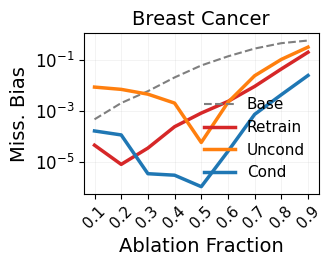

Saved: figures/breast_cancer_kl_fractionwise.pdf


In [5]:
title, data, fname = datasets[2]

fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))

for key, label, color, ls, lw in methods:
    ax.plot(FRACS, data[key], linestyle=ls, linewidth=lw,
            color=color, label=label)

ax.set_xlabel('Ablation Fraction', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Miss. Bias', fontsize=LABEL_FONTSIZE)
ax.set_yscale('log')
ax.set_xticks(FRACS)
ax.set_xticklabels([str(f) for f in FRACS], rotation=45, fontsize=TICK_LABELSIZE - 1)
ax.tick_params(axis='y', which='major', labelsize=TICK_LABELSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE - 1, loc='lower right', frameon=False)
ax.grid(True, alpha=GRID_ALPHA, linewidth=0.5)
ax.set_title(title, fontsize=LABEL_FONTSIZE)

plt.tight_layout(pad=TIGHT_PAD)
plt.savefig(output_dir / f'{fname}_kl_fractionwise.pdf', dpi=300, bbox_inches='tight')
plt.savefig(output_dir / f'{fname}_kl_fractionwise.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: figures/{fname}_kl_fractionwise.pdf')